In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

CHECKING CUDA COMPATIBILITY
Current PyTorch version: 2.2.0+cu118
Using PyTorch: 2.2.0+cu118
✅ GPU Detected: Tesla P100-PCIE-16GB
✅ VRAM: 17.1 GB
Using device: cuda

🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬
ICTSP ZERO-SHOT LEARNING - EXCHANGE & WEATHER
LEARNABLE CHANNEL PROJECTION - PRESERVES ALL INFORMATION
Directions (2): Exchange → Weather, Weather → Exchange
Methods (4): Baseline, STL, Wavelet, SSA
Prediction Lengths (2): 96, 192
Total: 16 experiments
🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬

🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
ICTSP ZERO-SHOT LEARNING - EXCHANGE & WEATHER
LEARNABLE CHANNEL PROJECTION - PRESERVES ALL INFORMATION
Total: 2 directions × 4 methods × 2 pred_lens = 16 experiments
Device: cuda
🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥

▶️  [1/16] Exchange → Weather | Baseline | pred_len=96

[1/16] Exchange → Weather
Method: Baseline | pred_len=96

[1/4] Loading data...
Loading Exchange dataset...
✅ Loaded Exchange: 8 channels, 75

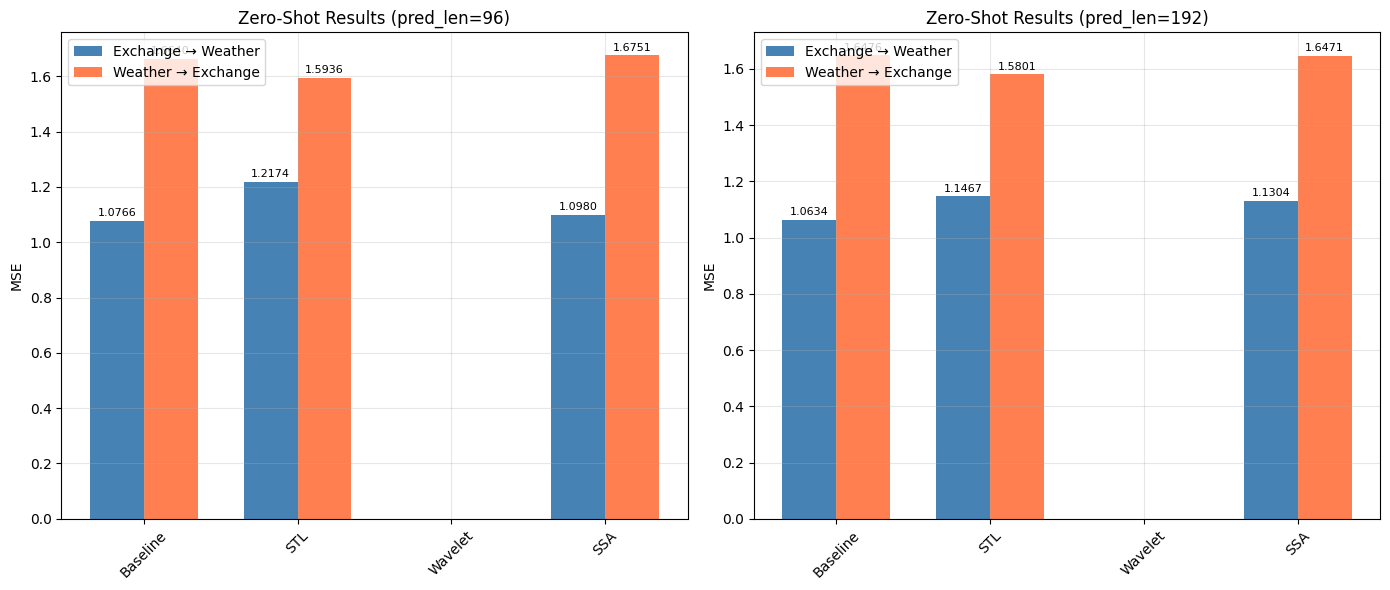


✅ DONE! Files saved:
   - exchange_weather_projection_results.csv
   - exchange_weather_projection_final.json
   - exchange_weather_projection_plot.png


In [4]:
# ============================================================================
# ICTSP ZERO-SHOT LEARNING - EXCHANGE & WEATHER
# LEARNABLE CHANNEL PROJECTION - PRESERVES ALL INFORMATION
# 2 Directions × 4 Methods × 2 pred_lens = 16 experiments
# ============================================================================

import os
import gc
import json
import time
import random
import warnings
import subprocess
import sys
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# ============================================================================
# CUDA COMPATIBILITY FIX FOR KAGGLE P100
# ============================================================================
print("=" * 60)
print("CHECKING CUDA COMPATIBILITY")
print("=" * 60)

current_version = torch.__version__
print(f"Current PyTorch version: {current_version}")

needs_reinstall = False
if "2.10" in current_version or "2.9" in current_version:
    needs_reinstall = True
    print("⚠️ PyTorch version may be incompatible with Kaggle P100")

if needs_reinstall:
    print("Installing compatible PyTorch 2.2.0 with CUDA 11.8...")
    subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "-y", "torch", "torchvision", "torchaudio"], 
                          stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    subprocess.check_call([sys.executable, "-m", "pip", "install", 
                           "torch==2.2.0", 
                           "torchvision==0.17.0", 
                           "torchaudio==2.2.0", 
                           "--index-url", "https://download.pytorch.org/whl/cu118"],
                          stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    print("✅ PyTorch 2.2.0 installed")
    print("⚠️ PLEASE RESTART YOUR KERNEL and run this cell again!")
    import os
    os._exit(0)

import torch
print(f"Using PyTorch: {torch.__version__}")

if torch.cuda.is_available():
    device = torch.device("cuda")
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"✅ GPU Detected: {gpu_name}")
    print(f"✅ VRAM: {vram_gb:.1f} GB")
else:
    device = torch.device("cpu")
    print("⚠️ No GPU detected, using CPU")

print(f"Using device: {device}")
print("=" * 60)

# -----------------------------------------------------------------------------
# OPTIONAL PACKAGES
# -----------------------------------------------------------------------------
try:
    import pywt
    HAS_PYWT = True
except ImportError:
    HAS_PYWT = False
    subprocess.check_call(["pip", "install", "-q", "PyWavelets"])
    import pywt
    HAS_PYWT = True

try:
    from statsmodels.tsa.seasonal import STL as STLModel
    HAS_STL = True
except ImportError:
    HAS_STL = False
    subprocess.check_call(["pip", "install", "-q", "statsmodels"])
    from statsmodels.tsa.seasonal import STL as STLModel
    HAS_STL = True

try:
    import gdown
    HAS_GDOWN = True
except ImportError:
    HAS_GDOWN = False
    subprocess.check_call(["pip", "install", "-q", "gdown"])
    import gdown
    HAS_GDOWN = True


# ============================================================================
# REPRODUCIBILITY
# ============================================================================
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(2024)


# ============================================================================
# RECONSTRUCTION METHODS
# ============================================================================

class STLDecomposition:
    @staticmethod
    def get_period(dataset_name: str) -> int:
        if "Exchange" in dataset_name:
            return 7
        elif "Weather" in dataset_name:
            return 144
        return 24

    @staticmethod
    def denoise_signal(signal: np.ndarray, period: int, robust: bool = True) -> np.ndarray:
        if not HAS_STL:
            return signal
        signal = signal.copy()
        if np.any(np.isnan(signal)):
            mask = np.isnan(signal)
            if np.any(~mask):
                signal[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), signal[~mask])
            else:
                return signal.astype(np.float32)
        if np.std(signal) < 1e-8 or len(signal) < 2 * period:
            return signal.astype(np.float32)
        try:
            stl = STLModel(signal, period=period, robust=robust)
            result = stl.fit()
            denoised = result.trend + result.seasonal
            bad = np.isnan(denoised)
            denoised[bad] = signal[bad]
            return denoised.astype(np.float32)
        except Exception:
            return signal.astype(np.float32)

    @staticmethod
    def apply_to_multivariate(data: np.ndarray, dataset_name: str, robust: bool = True) -> np.ndarray:
        period = STLDecomposition.get_period(dataset_name)
        out = np.zeros_like(data, dtype=np.float32)
        for c in range(data.shape[1]):
            out[:, c] = STLDecomposition.denoise_signal(data[:, c], period, robust)
        return out


class WaveletReconstruction:
    @staticmethod
    def denoise_signal(signal: np.ndarray, wavelet: str = "db4", level: int = 2, threshold_factor: float = 0.1) -> np.ndarray:
        if not HAS_PYWT:
            return signal
        signal = signal.copy()
        if np.any(np.isnan(signal)):
            mask = np.isnan(signal)
            if np.any(~mask):
                signal[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), signal[~mask])
            else:
                return signal.astype(np.float32)
        if np.std(signal) < 1e-8:
            return signal.astype(np.float32)
        max_level = max(1, int(np.log2(len(signal))) - 1)
        level = min(level, max_level)
        try:
            coeffs = pywt.wavedec(signal, wavelet, level=level)
            if len(coeffs) > 1:
                sigma = np.median(np.abs(coeffs[-1])) / 0.6745
                threshold = sigma * np.sqrt(2 * np.log(len(signal))) * threshold_factor
                coeffs_thresh = [coeffs[0]]
                for i in range(1, len(coeffs)):
                    coeffs_thresh.append(pywt.threshold(coeffs[i], threshold, mode="soft"))
                out = pywt.waverec(coeffs_thresh, wavelet)[:len(signal)]
            else:
                out = signal
            return out.astype(np.float32)
        except Exception:
            return signal.astype(np.float32)

    @staticmethod
    def apply_to_multivariate(data: np.ndarray, wavelet: str = "db4", level: int = 2, threshold_factor: float = 0.1) -> np.ndarray:
        out = np.zeros_like(data, dtype=np.float32)
        for c in range(data.shape[1]):
            out[:, c] = WaveletReconstruction.denoise_signal(data[:, c], wavelet, level, threshold_factor)
        return out


class SSARecovery:
    @staticmethod
    def _embed(signal: np.ndarray, L: int) -> np.ndarray:
        N = len(signal)
        K = N - L + 1
        X = np.zeros((L, K), dtype=np.float32)
        for i in range(L):
            X[i, :] = signal[i:i + K]
        return X

    @staticmethod
    def _diagonal_averaging(X: np.ndarray) -> np.ndarray:
        L, K = X.shape
        N = L + K - 1
        signal = np.zeros(N, dtype=np.float32)
        counts = np.zeros(N, dtype=np.float32)
        for i in range(L):
            for j in range(K):
                signal[i + j] += X[i, j]
                counts[i + j] += 1.0
        return signal / np.maximum(counts, 1e-8)

    @staticmethod
    def denoise_signal(signal: np.ndarray, L: int = 30, r: int = 5) -> np.ndarray:
        signal = signal.copy()
        N = len(signal)
        if N < L:
            L = max(2, N // 2)
        if np.any(np.isnan(signal)):
            mask = np.isnan(signal)
            if np.any(~mask):
                signal[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), signal[~mask])
            else:
                return signal.astype(np.float32)
        if np.std(signal) < 1e-8:
            return signal.astype(np.float32)
        try:
            X = SSARecovery._embed(signal, L)
            U, S, Vt = np.linalg.svd(X, full_matrices=False)
            r = min(r, len(S))
            Xr = U[:, :r] @ np.diag(S[:r]) @ Vt[:r, :]
            out = SSARecovery._diagonal_averaging(Xr)[:N]
            return out.astype(np.float32)
        except Exception:
            return signal.astype(np.float32)

    @staticmethod
    def apply_to_multivariate(data: np.ndarray, L: int = 30, r: int = 5) -> np.ndarray:
        out = np.zeros_like(data, dtype=np.float32)
        for c in range(data.shape[1]):
            out[:, c] = SSARecovery.denoise_signal(data[:, c], L, r)
        return out


def apply_reconstruction(data: np.ndarray, use_stl: bool, use_wavelet: bool, use_ssa: bool, dataset_name: str) -> np.ndarray:
    if use_stl:
        return STLDecomposition.apply_to_multivariate(data, dataset_name, robust=True)
    elif use_wavelet:
        return WaveletReconstruction.apply_to_multivariate(data, "db4", 2, 0.1)
    elif use_ssa:
        return SSARecovery.apply_to_multivariate(data, 30, 5)
    return data.astype(np.float32)


# ============================================================================
# DATA LOADING (FIXED FOR EXCHANGE DATASET)
# ============================================================================

class DataManager:
    DATASET_URLS = {
        "Exchange": "https://raw.githubusercontent.com/laiguokun/multivariate-time-series-data/master/exchange_rate/exchange_rate.txt.gz",
    }
    
    WEATHER_URL = "https://drive.google.com/uc?export=download&id=1Tc7GeVN7DLEl-RAs-JVwG9yFMf--S8dy"

    @staticmethod
    def load_exchange_data() -> np.ndarray:
        url = DataManager.DATASET_URLS["Exchange"]
        import gzip
        from io import BytesIO
        import urllib.request
        
        print("Loading Exchange dataset...")
        
        with urllib.request.urlopen(url) as response:
            compressed = response.read()
            with gzip.open(BytesIO(compressed), 'rt') as f:
                content = f.read()
        
        data = []
        lines = content.strip().split('\n')
        
        for line in lines:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) > 1:
                try:
                    row = [float(x) for x in parts]
                    data.append(row)
                    continue
                except:
                    pass
            parts = line.split(',')
            if len(parts) > 1:
                try:
                    row = [float(x) for x in parts]
                    data.append(row)
                    continue
                except:
                    pass
        
        df = pd.DataFrame(data)
        values = df.values.astype(np.float32)
        
        if np.any(np.isnan(values)) or np.any(np.isinf(values)):
            values = np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0)
        
        print(f"✅ Loaded Exchange: {values.shape[1]} channels, {values.shape[0]} time steps")
        return values

    @staticmethod
    def load_weather_data() -> np.ndarray:
        print("Loading Weather dataset...")
        output = "weather.csv"
        if not os.path.exists(output):
            gdown.download(DataManager.WEATHER_URL, output, quiet=False)
        df = pd.read_csv(output)
        if 'date' in df.columns:
            df = df.drop(columns=['date'])
        
        values = df.values.astype(np.float32)
        
        if np.any(np.isnan(values)) or np.any(np.isinf(values)):
            values = np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0)
        
        print(f"✅ Loaded Weather: {values.shape}")
        return values

    @staticmethod
    def load_raw(name: str) -> np.ndarray:
        if name == "Weather":
            return DataManager.load_weather_data()
        elif name == "Exchange":
            return DataManager.load_exchange_data()
        else:
            raise ValueError(f"Unknown dataset: {name}")


class WindowDataset(Dataset):
    def __init__(self, data: np.ndarray, seq_len: int, pred_len: int):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.window_len = seq_len + pred_len
        if len(data) >= self.window_len:
            self.n_windows = len(data) - self.window_len + 1
        else:
            self.n_windows = 0
    
    def __len__(self):
        return self.n_windows
    
    def __getitem__(self, idx):
        window = self.data[idx:idx + self.window_len]
        x_enc = window[:self.seq_len]
        y = window[self.seq_len:self.seq_len + self.pred_len]
        x_mark_dec_dummy = torch.zeros(self.seq_len + self.pred_len, 1)
        return x_enc, y, x_mark_dec_dummy


# ============================================================================
# COMPLETE ICTSP ARCHITECTURE
# ============================================================================

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_size, heads, dropout=0.1):
        super().__init__()
        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads
        self.dropout = nn.Dropout(dropout)
        assert self.head_dim * heads == embed_size
        self.values = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.keys = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.queries = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.fc_out = nn.Linear(heads * self.head_dim, embed_size)

    def forward(self, values, keys, queries, mask=None):
        N = queries.shape[0]
        value_len, key_len, query_len = values.shape[1], keys.shape[1], queries.shape[1]
        values = values.reshape(N, value_len, self.heads, self.head_dim)
        keys = keys.reshape(N, key_len, self.heads, self.head_dim)
        queries = queries.reshape(N, query_len, self.heads, self.head_dim)
        values = self.values(values)
        keys = self.dropout(self.keys(keys))
        queries = self.queries(queries)
        energy = torch.einsum("nqhd,nkhd->nhqk", [queries, keys])
        if mask is not None:
            energy = energy.masked_fill(mask == 0, float("-1e20"))
        energy = energy / (self.embed_size ** 0.5)
        attention = F.softmax(energy, dim=-1)
        out = torch.einsum("nhql,nlhd->nqhd", [attention, values]).reshape(
            N, query_len, self.heads * self.head_dim
        )
        out = self.fc_out(out)
        return out, attention


class TransformerEncoder(nn.Module):
    def __init__(self, emb_size=128, depth=3, heads=8, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=emb_size,
                nhead=heads,
                dim_feedforward=mlp_ratio * emb_size,
                batch_first=True,
                dropout=dropout,
                norm_first=False,
                activation="gelu",
            )
            for _ in range(depth)
        ])

    def forward(self, x, mask=None):
        for layer in self.layers:
            x = layer(x, src_mask=mask)
        return x


class Tokenizer(nn.Module):
    def __init__(self, lookback=512, output=96, stride=8):
        super().__init__()
        self.d = lookback + output
        self.s = stride

    def forward(self, tensor):
        B, C, L = tensor.shape
        if L >= self.d:
            unfolded = tensor.flip(-1).unfold(dimension=2, size=self.d, step=self.s)
            return unfolded.flip(-1).flip(-2)
        else:
            padding = torch.zeros(B, C, self.d - L, device=tensor.device, dtype=tensor.dtype)
            tensor_padded = torch.cat([tensor, padding], dim=-1)
            unfolded = tensor_padded.flip(-1).unfold(dimension=2, size=self.d, step=self.s)
            return unfolded.flip(-1).flip(-2)


def normalize_vectors(x):
    norms = torch.norm(x, p=2, dim=-1, keepdim=True).clamp_min(1e-8)
    return x / norms


class TokenFusionLayerWithAdjustableRatio(nn.Module):
    def __init__(self, input_dim, fusion_ratio=0.1, init_reduce_rate=8, batch_size=2048):
        super().__init__()
        self.input_dim = input_dim
        self.fusion_ratio = fusion_ratio
        self.init_reduce_rate = init_reduce_rate
        self.batch_size = batch_size
        self.input_q = nn.Linear(input_dim // 2, 32)
        self.input_k = nn.Linear(input_dim // 2, 32)
        self.silu = nn.ReLU()

    def forward(self, x, num_target_tokens, limit=2048):
        target_tokens = x[:, -num_target_tokens:]
        other_tokens = x[:, :-num_target_tokens]

        if other_tokens.shape[1] == 0:
            return x

        attention_scores = torch.zeros((x.size(0), other_tokens.size(1)), device=x.device)

        for start_idx in range(0, other_tokens.size(1), self.batch_size):
            end_idx = min(start_idx + self.batch_size, other_tokens.size(1))
            batch_other_tokens = other_tokens[:, start_idx:end_idx]
            batch_other_tokens_expanded = normalize_vectors(
                self.input_q(batch_other_tokens[:, :, -batch_other_tokens.shape[-1] // 2:])
            ).unsqueeze(1)

            cosine_sims = F.cosine_similarity(
                batch_other_tokens_expanded,
                normalize_vectors(self.input_k(target_tokens[:, :, -batch_other_tokens.shape[-1] // 2:])).unsqueeze(2),
                dim=-1
            )
            cosine_sims = self.silu(cosine_sims)
            attention_scores[:, start_idx:end_idx] = cosine_sims.mean(dim=1)

        sorted_scores, sorted_indices = torch.sort(attention_scores, descending=True, dim=1)

        num_keep = int(other_tokens.size(1) * self.fusion_ratio)
        num_keep = max(1, min(num_keep, other_tokens.size(1)))

        top_indices = sorted_indices[:, :num_keep]
        top_tokens = other_tokens.gather(
            1, top_indices.unsqueeze(-1).expand(-1, -1, other_tokens.size(2))
        )
        top_scores = attention_scores.gather(1, top_indices)
        fused_tokens = [top_tokens * top_scores.unsqueeze(-1)]

        remaining_indices = sorted_indices[:, num_keep:]
        remaining = max(0, limit - num_keep)
        fusion_step = self.init_reduce_rate

        while remaining > 0 and remaining_indices.shape[1] >= fusion_step:
            num_to_fuse = max(int(remaining * self.fusion_ratio), fusion_step)
            num_to_fuse = min(num_to_fuse, remaining_indices.shape[1])
            num_groups = num_to_fuse // fusion_step

            if num_groups <= 0:
                break

            group_tokens = torch.zeros((x.size(0), num_groups, x.size(2)), device=x.device)
            group_scores = torch.zeros((x.size(0), num_groups), device=x.device)

            for i in range(num_groups):
                s = i * fusion_step
                e = s + fusion_step
                slice_idx = remaining_indices[:, s:e]
                slice_tokens = other_tokens.gather(
                    1, slice_idx.unsqueeze(-1).expand(-1, -1, other_tokens.size(2))
                )
                slice_scores = attention_scores.gather(1, slice_idx)
                weights = F.softmax(slice_scores, dim=1)
                group_tokens[:, i, :] = torch.sum(slice_tokens * weights.unsqueeze(-1), dim=1)
                group_scores[:, i] = torch.sum(slice_scores * weights, dim=1)

            fused_tokens.append(group_tokens * group_scores.unsqueeze(-1))
            remaining_indices = remaining_indices[:, num_to_fuse:]
            remaining -= num_to_fuse
            fusion_step *= self.init_reduce_rate

        output_tokens = torch.cat(fused_tokens, dim=1)
        output_tokens = output_tokens[:, 0:min(limit, output_tokens.shape[1]), :]
        output_tokens = torch.cat([torch.flip(output_tokens, [1]), target_tokens], dim=1)
        return output_tokens


class ICTSP(nn.Module):
    def __init__(
        self,
        lookback=512,
        output=96,
        depth=3,
        heads=8,
        mlp_ratio=4,
        d_model=128,
        emb_init=0.01,
        external_stride=8,
        dropout=0.5,
        token_retriever_flag=True,
        linear_warmup_steps=5000,
        token_limit=2048,
    ):
        super().__init__()

        self.lookback = lookback
        self.pred_len = output
        self.external_stride = external_stride

        self.input_projection = nn.Linear(lookback + output, d_model)
        self.transformer_encoder = TransformerEncoder(d_model, depth, heads, mlp_ratio, dropout)
        self.input_norm = nn.LayerNorm(d_model)
        self.output_norm = nn.LayerNorm(d_model)

        self.output_embedding = nn.Parameter(emb_init * torch.randn(1, 1, 1200))
        self.output_projection = nn.Linear(d_model, output)

        self.channel_discerning_mask = nn.Parameter(emb_init * torch.randn(1, 1024, d_model))
        self.in_context_positional_embedding = nn.Parameter(emb_init * torch.randn(1, 8192, 1, d_model))
        self.in_context_positional_embedding_after = nn.Parameter(emb_init * torch.randn(1, 8192, d_model))

        self.token_retriever_flag = token_retriever_flag
        self.linear_warmup_steps = linear_warmup_steps
        self.token_merger = TokenFusionLayerWithAdjustableRatio(d_model, 0.1, 8, batch_size=2048)
        self.token_limit = token_limit
        self.linear_warm_up_counter = 0

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if isinstance(module, nn.Linear) and module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.LayerNorm):
            if module.bias is not None:
                nn.init.zeros_(module.bias)
            if module.weight is not None:
                nn.init.ones_(module.weight)

    def forward(self, x, x_mark_dec=None):
        lookback = self.lookback
        future = self.pred_len
        mean = x[:, [-1], :].detach()

        x = x.permute(0, 2, 1)
        output_embedding = self.output_embedding[:, :, 0:future].expand(x.shape[0], x.shape[1], -1)
        x = torch.cat([x, output_embedding + mean.permute(0, 2, 1)], dim=-1)

        number_of_targets = x.shape[1]
        x_orig = x[:, :, 0:-future].clone()

        B, C, _ = x.shape
        x_target = x[:, -number_of_targets:, -(lookback + future):]

        external_tokenizer = Tokenizer(lookback, future, stride=self.external_stride)
        ex_tokens = external_tokenizer(x_orig)
        _, _, _, d = ex_tokens.shape
        ex_tokens = ex_tokens.permute(0, 2, 1, 3).reshape(B, -1, d)

        x_tokens = torch.cat([ex_tokens, x_target], dim=1)
        token_mean = x_tokens[:, :, [-(future + 1)]].detach()
        x_tokens = x_tokens - token_mean
        x_tokens = self.input_projection(x_tokens)

        channel_discerning_mask = self.channel_discerning_mask[:, -C:, :]
        x_tokens = x_tokens + channel_discerning_mask.repeat(1, x_tokens.shape[1] // C, 1)

        in_context_positional_embedding = self.in_context_positional_embedding[:, -(x_tokens.shape[1] // C):, :, :].expand(-1, -1, C, -1)
        in_context_positional_embedding = in_context_positional_embedding.reshape(
            in_context_positional_embedding.shape[0],
            in_context_positional_embedding.shape[1] * in_context_positional_embedding.shape[2],
            in_context_positional_embedding.shape[3],
        )
        x_tokens = x_tokens + in_context_positional_embedding

        if self.linear_warm_up_counter < self.linear_warmup_steps:
            if self.training:
                self.linear_warm_up_counter += 1
            x_output = self.output_projection(x_tokens[:, -number_of_targets:, :])
            x_output = x_output + token_mean[:, -x_output.shape[1]:, :]
            x_output = x_output.permute(0, 2, 1)
            return x_output

        if self.token_retriever_flag:
            x_tokens = self.token_merger(x_tokens, number_of_targets, limit=self.token_limit)

        x_tokens = x_tokens + self.in_context_positional_embedding_after[:, -x_tokens.shape[1]:, :]

        limit = self.token_limit
        x_tokens = x_tokens[:, -limit:, :]
        x_tokens = self.input_norm(x_tokens)
        x_tokens = self.transformer_encoder(x_tokens)
        x_output = x_tokens[:, -number_of_targets:, :]
        x_output = self.output_projection(x_output)
        x_output = x_output + token_mean[:, -x_output.shape[1]:, :]
        x_output = x_output.permute(0, 2, 1)

        return x_output


class RepoICTSPModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.model = ICTSP(
            lookback=cfg.lookback,
            output=cfg.pred_len,
            depth=cfg.e_layers,
            heads=cfg.n_heads,
            mlp_ratio=cfg.mlp_ratio,
            d_model=cfg.d_model,
            external_stride=cfg.sampling_step,
            dropout=cfg.dropout,
            token_retriever_flag=cfg.token_retriever_flag,
            linear_warmup_steps=cfg.model_linear_warmup_steps,
            token_limit=cfg.token_limit,
        )

    def forward(self, x, x_mark_dec):
        return self.model(x, x_mark_dec)


# ============================================================================
# LEARNABLE CHANNEL PROJECTION - PRESERVES ALL INFORMATION
# ============================================================================

class LearnableChannelProjection(nn.Module):
    """
    Learnable projection that preserves ALL channel information.
    Maps from input channels to output channels without truncation.
    """
    def __init__(self, input_channels: int, output_channels: int):
        super().__init__()
        self.input_channels = input_channels
        self.output_channels = output_channels
        
        # Learnable linear projection
        self.projection = nn.Linear(input_channels, output_channels)
        
        # Initialize weights for stable training
        nn.init.xavier_uniform_(self.projection.weight)
        nn.init.zeros_(self.projection.bias)
        
        print(f"  📐 Created LearnableChannelProjection: {input_channels} → {output_channels}")
    
    def forward(self, x):
        """
        x: [batch, seq_len, input_channels]
        returns: [batch, seq_len, output_channels]
        """
        return self.projection(x)


# ============================================================================
# BASELINES
# ============================================================================

class LastValueBaseline(nn.Module):
    def forward(self, history, horizon):
        return history[:, -1:, :].repeat(1, horizon, 1)


class NLinearBaseline(nn.Module):
    def __init__(self, seq_len, horizon, num_channels):
        super().__init__()
        self.linears = nn.ModuleList([nn.Linear(seq_len, horizon) for _ in range(num_channels)])

    def forward(self, history):
        return torch.stack([self.linears[c](history[:, :, c]) for c in range(history.shape[-1])], dim=2)


# ============================================================================
# CONFIGURATION
# ============================================================================

@dataclass
class Config:
    dataset_name: str = "Exchange"
    experiment_mode: str = "zero_shot"
    
    use_stl: bool = False
    use_wavelet: bool = False
    use_ssa: bool = False
    
    seq_len: int = 512
    lookback: int = 512
    pred_len: int = 96
    
    e_layers: int = 3
    d_model: int = 128
    n_heads: int = 8
    mlp_ratio: int = 4
    dropout: float = 0.5
    sampling_step: int = 8
    token_retriever_flag: bool = True
    token_limit: int = 2048
    
    batch_size: int = 16
    batch_size_test: int = 16
    learning_rate: float = 5e-4
    weight_decay: float = 1e-5
    train_epochs: int = 50
    grad_clip: float = 1.0
    
    eval_interval: int = 200
    patience_steps: int = 6000
    
    enc_in: int = 8
    model_linear_warmup_steps: int = 5000
    
    seed: int = 2024
    device: str = device


# ============================================================================
# METRICS & EVALUATION
# ============================================================================

def compute_metrics(pred, target):
    with torch.no_grad():
        mse = F.mse_loss(pred, target).item()
        mae = F.l1_loss(pred, target).item()
    return mse, mae


@torch.no_grad()
def evaluate(model, loader, device, channel_projection=None):
    model.eval()
    total_mse = 0.0
    total_mae = 0.0
    n_batches = 0
    
    for x_enc, y, x_mark_dec in loader:
        x_enc = x_enc.to(device)
        y = y.to(device)
        x_mark_dec = x_mark_dec.to(device)
        
        # Apply channel projection if needed (preserves all information!)
        if channel_projection is not None:
            x_enc = channel_projection(x_enc)
        
        pred = model(x_enc, x_mark_dec)
        
        # Ensure dimensions match for metrics
        if pred.shape[-1] != y.shape[-1]:
            min_c = min(pred.shape[-1], y.shape[-1])
            pred = pred[:, :, :min_c]
            y = y[:, :, :min_c]
        
        mse, mae = compute_metrics(pred, y)
        total_mse += mse
        total_mae += mae
        n_batches += 1
    
    return {
        "mse": total_mse / n_batches if n_batches > 0 else float("inf"),
        "mae": total_mae / n_batches if n_batches > 0 else float("inf"),
    }


# ============================================================================
# ZERO-SHOT TRAINER WITH LEARNABLE PROJECTION
# ============================================================================

class ZeroShotTrainer:
    def __init__(self, cfg: Config, source_name: str, target_name: str, method_name: str, exp_id: int, total: int):
        self.cfg = cfg
        self.device = cfg.device
        self.source_name = source_name
        self.target_name = target_name
        self.method_name = method_name
        self.exp_id = exp_id
        self.total = total
        set_seed(cfg.seed)
        
        print(f"\n{'='*60}")
        print(f"[{exp_id}/{total}] {source_name} → {target_name}")
        print(f"Method: {method_name} | pred_len={cfg.pred_len}")
        print(f"{'='*60}")
    
    def prepare_data(self):
        print(f"\n[1/4] Loading data...")
        
        source_values = DataManager.load_raw(self.source_name)
        target_values = DataManager.load_raw(self.target_name)
        
        # Store original channel counts (NO TRUNCATION - preserve ALL channels!)
        self.source_channels = source_values.shape[1]
        self.target_channels = target_values.shape[1]
        
        print(f"  Source {self.source_name}: {source_values.shape}")
        print(f"  Target {self.target_name}: {target_values.shape}")
        print(f"  Source channels: {self.source_channels}")
        print(f"  Target channels: {self.target_channels}")
        
        print(f"\n[2/4] Applying reconstruction...")
        source_reconstructed = apply_reconstruction(
            source_values, self.cfg.use_stl, self.cfg.use_wavelet, self.cfg.use_ssa, self.source_name
        )
        target_reconstructed = apply_reconstruction(
            target_values, self.cfg.use_stl, self.cfg.use_wavelet, self.cfg.use_ssa, self.target_name
        )
        
        # CRITICAL: NO CHANNEL TRUNCATION!
        # Keep ALL original channels - preserve ALL information
        print(f"\n[3/4] Preserving all channels (no truncation)...")
        print(f"  Source keeps all {self.source_channels} channels")
        print(f"  Target keeps all {self.target_channels} channels")
        
        # Create train/val split for source (70% train, 10% val)
        n_total = len(source_reconstructed)
        n_train = int(n_total * 0.70)
        n_val = int(n_total * 0.10)
        
        train_data = source_reconstructed[:n_train]
        val_data = source_reconstructed[n_train:n_train + n_val]
        
        print(f"\n[4/4] Standardizing each dataset independently...")
        
        # Source scaling (fitted on source training data)
        self.source_scaler = StandardScaler()
        train_scaled = self.source_scaler.fit_transform(train_data).astype(np.float32)
        val_scaled = self.source_scaler.transform(val_data).astype(np.float32)
        
        # Target scaling (independent - preserves target's natural distribution)
        self.target_scaler = StandardScaler()
        target_scaled = self.target_scaler.fit_transform(target_reconstructed).astype(np.float32)
        
        # Use last 30% of target for zero-shot testing
        n_test_start = int(len(target_scaled) * 0.70)
        test_data = target_scaled[n_test_start:]
        
        print(f"  Train samples: {len(train_scaled)}")
        print(f"  Val samples: {len(val_scaled)}")
        print(f"  Test samples: {len(test_data)}")
        
        # Update cfg.enc_in to source channels (model trained on source dimensions)
        self.cfg.enc_in = self.source_channels
        
        # Create datasets (each with its own channel count - NO TRUNCATION)
        self.train_ds = WindowDataset(train_scaled, self.cfg.seq_len, self.cfg.pred_len)
        self.val_ds = WindowDataset(val_scaled, self.cfg.seq_len, self.cfg.pred_len)
        self.test_ds = WindowDataset(test_data, self.cfg.seq_len, self.cfg.pred_len)
        
        self.train_loader = DataLoader(self.train_ds, batch_size=self.cfg.batch_size, shuffle=True, num_workers=0)
        self.val_loader = DataLoader(self.val_ds, batch_size=self.cfg.batch_size_test, shuffle=False, num_workers=0)
        self.test_loader = DataLoader(self.test_ds, batch_size=self.cfg.batch_size_test, shuffle=False, num_workers=0)
        
        print(f"  Train windows: {len(self.train_ds)}")
        print(f"  Val windows: {len(self.val_ds)}")
        print(f"  Test windows: {len(self.test_ds)}")
        
        # ============ CREATE LEARNABLE CHANNEL PROJECTION ============
        # IMPORTANT: Project from TARGET channels to SOURCE channels
        # Because model expects source channels, target has different channels
        if self.source_channels != self.target_channels:
            # Project target data to match source channel count
            # input: target_channels, output: source_channels
            print(f"\n  🔧 Creating LearnableChannelProjection:")
            print(f"     Target has {self.target_channels} channels, Model expects {self.source_channels} channels")
            print(f"     Projection: {self.target_channels} → {self.source_channels}")
            self.channel_projection = LearnableChannelProjection(self.target_channels, self.source_channels)
            self.channel_projection = self.channel_projection.to(self.device)
        else:
            print(f"\n  ✅ Same channel count ({self.source_channels}), no projection needed")
            self.channel_projection = None
    
    def train(self):
        print(f"\n[4/4] Training on {self.source_name}...")
        
        self.model = RepoICTSPModel(self.cfg).to(self.device)
        total_params = sum(p.numel() for p in self.model.parameters())
        print(f"  Model parameters: {total_params:,}")
        
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=self.cfg.learning_rate, weight_decay=self.cfg.weight_decay)
        
        best_val_mse = float("inf")
        best_state = None
        steps_without_improvement = 0
        total_steps = 0
        
        for epoch in range(1, self.cfg.train_epochs + 1):
            self.model.train()
            epoch_loss = 0.0
            n_batches = 0
            
            for x_enc, y, x_mark_dec in self.train_loader:
                x_enc = x_enc.to(self.device)
                y = y.to(self.device)
                x_mark_dec = x_mark_dec.to(self.device)
                
                optimizer.zero_grad(set_to_none=True)
                pred = self.model(x_enc, x_mark_dec)
                loss = F.mse_loss(pred, y)
                loss.backward()
                
                if self.cfg.grad_clip > 0:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg.grad_clip)
                
                optimizer.step()
                
                epoch_loss += loss.item()
                n_batches += 1
                total_steps += 1
                
                if total_steps % self.cfg.eval_interval == 0:
                    self.model.eval()
                    val_metrics = evaluate(self.model, self.val_loader, self.device)
                    
                    if val_metrics["mse"] < best_val_mse - 1e-8:
                        best_val_mse = val_metrics["mse"]
                        best_state = {k: v.detach().cpu().clone() for k, v in self.model.state_dict().items()}
                        steps_without_improvement = 0
                        if epoch % 5 == 0:
                            print(f"  Epoch {epoch:3d} | Step {total_steps} | Val MSE {val_metrics['mse']:.6f} ✓")
                    else:
                        steps_without_improvement += self.cfg.eval_interval
                        if epoch % 5 == 0:
                            print(f"  Epoch {epoch:3d} | Step {total_steps} | Val MSE {val_metrics['mse']:.6f}")
                    
                    if steps_without_improvement >= self.cfg.patience_steps:
                        print(f"  Early stopping at epoch {epoch}, step {total_steps}")
                        self.model.train()
                        break
                    
                    self.model.train()
            
            if steps_without_improvement >= self.cfg.patience_steps:
                break
        
        if best_state is not None:
            self.model.load_state_dict(best_state)
        
        print(f"  Best Val MSE: {best_val_mse:.6f}")
        return best_val_mse
    
    def evaluate_zero_shot(self):
        print(f"\n  📊 Zero-shot evaluation on {self.target_name}...")
        print(f"  Using LearnableChannelProjection: {self.target_channels} → {self.source_channels}")
        
        # Pass channel projection model to evaluation
        test_metrics = evaluate(self.model, self.test_loader, self.device, self.channel_projection)
        print(f"  Zero-Shot MSE: {test_metrics['mse']:.6f}")
        print(f"  Zero-Shot MAE: {test_metrics['mae']:.6f}")
        return test_metrics
    
    def evaluate_baselines(self):
        print(f"\n  📊 Baseline evaluation on {self.target_name}...")
        results = {}
        
        # Last Value Baseline
        lv = LastValueBaseline()
        lv_mse = []
        
        for x_enc, y, _ in self.test_loader:
            x_enc = x_enc.to(self.device)
            y = y.to(self.device)
            
            # Apply channel projection if needed (preserves information)
            if self.channel_projection is not None:
                x_enc = self.channel_projection(x_enc)
            
            pred = lv(x_enc, self.cfg.pred_len)
            
            # Handle dimension mismatch for baselines
            if pred.shape[-1] != y.shape[-1]:
                min_c = min(pred.shape[-1], y.shape[-1])
                pred = pred[:, :, :min_c]
                y_trimmed = y[:, :, :min_c]
                mse, _ = compute_metrics(pred, y_trimmed)
            else:
                mse, _ = compute_metrics(pred, y)
            
            lv_mse.append(mse)
        results["LastValue"] = float(np.mean(lv_mse)) if lv_mse else float("nan")
        
        # NLinear Baseline
        nlinear = NLinearBaseline(self.cfg.seq_len, self.cfg.pred_len, self.source_channels).to(self.device)
        opt = torch.optim.Adam(nlinear.parameters(), lr=1e-3)
        
        for _ in range(20):
            nlinear.train()
            for x_enc, y, _ in self.train_loader:
                x_enc = x_enc.to(self.device)
                y = y.to(self.device)
                opt.zero_grad(set_to_none=True)
                pred = nlinear(x_enc)
                loss = F.mse_loss(pred, y)
                loss.backward()
                opt.step()
        
        nlinear.eval()
        nlin_mse = []
        with torch.no_grad():
            for x_enc, y, _ in self.test_loader:
                x_enc = x_enc.to(self.device)
                y = y.to(self.device)
                
                # Apply channel projection if needed
                if self.channel_projection is not None:
                    x_enc = self.channel_projection(x_enc)
                
                pred = nlinear(x_enc)
                
                # Handle dimension mismatch
                if pred.shape[-1] != y.shape[-1]:
                    min_c = min(pred.shape[-1], y.shape[-1])
                    pred = pred[:, :, :min_c]
                    y_trimmed = y[:, :, :min_c]
                    mse, _ = compute_metrics(pred, y_trimmed)
                else:
                    mse, _ = compute_metrics(pred, y)
                
                nlin_mse.append(mse)
        results["NLinear"] = float(np.mean(nlin_mse)) if nlin_mse else float("nan")
        
        print(f"  LastValue MSE: {results['LastValue']:.6f}")
        print(f"  NLinear MSE: {results['NLinear']:.6f}")
        
        return results
    
    def cleanup(self):
        if hasattr(self, "model"):
            del self.model
        if hasattr(self, "channel_projection"):
            del self.channel_projection
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


# ============================================================================
# MAIN EXPERIMENT RUNNER
# ============================================================================

def run_exchange_weather_zero_shot():
    directions = [("Exchange", "Weather"), ("Weather", "Exchange")]
    methods = [
        ("Baseline", False, False, False),
        ("STL", True, False, False),
        ("Wavelet", False, True, False),
        ("SSA", False, False, True),
    ]
    pred_lengths = [96, 192]
    
    all_results = {}
    
    print("\n" + "🔥" * 50)
    print("ICTSP ZERO-SHOT LEARNING - EXCHANGE & WEATHER")
    print("LEARNABLE CHANNEL PROJECTION - PRESERVES ALL INFORMATION")
    print(f"Total: 2 directions × 4 methods × 2 pred_lens = 16 experiments")
    print(f"Device: {device}")
    print("🔥" * 50)
    
    total = len(directions) * len(methods) * len(pred_lengths)
    exp_id = 0
    start_time = time.time()
    
    for pred_len in pred_lengths:
        for source, target in directions:
            for method_name, use_stl, use_wavelet, use_ssa in methods:
                exp_id += 1
                key = f"{source}_to_{target}_{method_name}_pred{pred_len}"
                
                print("\n" + "=" * 70)
                print(f"▶️  [{exp_id}/{total}] {source} → {target} | {method_name} | pred_len={pred_len}")
                print("=" * 70)
                
                try:
                    cfg = Config(
                        pred_len=pred_len,
                        use_stl=use_stl,
                        use_wavelet=use_wavelet,
                        use_ssa=use_ssa,
                        batch_size=16,
                        batch_size_test=16,
                        train_epochs=50,
                    )
                    
                    trainer = ZeroShotTrainer(cfg, source, target, method_name, exp_id, total)
                    trainer.prepare_data()
                    
                    exp_start = time.time()
                    best_val = trainer.train()
                    train_time = time.time() - exp_start
                    
                    test_metrics = trainer.evaluate_zero_shot()
                    baseline_metrics = trainer.evaluate_baselines()
                    
                    all_results[key] = {
                        "source": source,
                        "target": target,
                        "method": method_name,
                        "pred_len": pred_len,
                        "source_channels": trainer.source_channels,
                        "target_channels": trainer.target_channels,
                        "ictsp_zero_shot_mse": test_metrics["mse"],
                        "ictsp_zero_shot_mae": test_metrics["mae"],
                        "best_val_mse": best_val,
                        "lastvalue_mse": baseline_metrics["LastValue"],
                        "nlinear_mse": baseline_metrics["NLinear"],
                        "training_time_seconds": train_time,
                    }
                    
                    trainer.cleanup()
                    
                    with open("exchange_weather_projection_results.json", "w") as f:
                        json.dump(all_results, f, indent=2, default=str)
                    
                    elapsed = time.time() - start_time
                    avg_time = elapsed / exp_id
                    remaining = avg_time * (total - exp_id)
                    print(f"\n⏱️  Progress: {exp_id}/{total} | Elapsed: {elapsed/60:.1f} min | Remaining: {remaining/60:.1f} min\n")
                    
                except Exception as e:
                    print(f"❌ Error: {e}")
                    import traceback
                    traceback.print_exc()
                    all_results[key] = {"error": str(e)}
                    gc.collect()
                    if torch.cuda.is_available():
                        torch.cuda.empty_cache()
    
    total_time = time.time() - start_time
    print("\n" + "=" * 60)
    print(f"✅ ALL EXPERIMENTS COMPLETED!")
    print(f"Total time: {total_time/60:.1f} minutes ({total_time/3600:.1f} hours)")
    print("=" * 60)
    
    return all_results


# ============================================================================
# RESULTS VISUALIZATION
# ============================================================================

def print_results_summary(results):
    print("\n" + "=" * 100)
    print("ZERO-SHOT RESULTS - EXCHANGE & WEATHER")
    print("Learnable Channel Projection - All Channels Preserved")
    print("=" * 100)
    
    results_list = []
    for key, val in results.items():
        if isinstance(val, dict) and "ictsp_zero_shot_mse" in val:
            results_list.append(val)
    
    if results_list:
        df = pd.DataFrame(results_list)
        
        for pred_len in [96, 192]:
            print(f"\n📊 pred_len = {pred_len}")
            print("-" * 80)
            sub_df = df[df['pred_len'] == pred_len]
            pivot = sub_df.pivot_table(
                values='ictsp_zero_shot_mse',
                index=['source', 'target'],
                columns='method',
                aggfunc='first'
            )
            print(pivot.round(6))
        
        df.to_csv("exchange_weather_projection_results.csv", index=False)
        print(f"\n✅ Saved to exchange_weather_projection_results.csv")
        
        # Create bar plot
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        methods_list = ['Baseline', 'STL', 'Wavelet', 'SSA']
        
        for idx, pred_len in enumerate([96, 192]):
            ax = axes[idx]
            sub_df = df[df['pred_len'] == pred_len]
            
            exchange_to_weather = []
            weather_to_exchange = []
            
            for method in methods_list:
                val1 = sub_df[(sub_df['source'] == 'Exchange') & (sub_df['target'] == 'Weather') & (sub_df['method'] == method)]['ictsp_zero_shot_mse'].values
                val2 = sub_df[(sub_df['source'] == 'Weather') & (sub_df['target'] == 'Exchange') & (sub_df['method'] == method)]['ictsp_zero_shot_mse'].values
                exchange_to_weather.append(val1[0] if len(val1) > 0 else 0)
                weather_to_exchange.append(val2[0] if len(val2) > 0 else 0)
            
            x = np.arange(len(methods_list))
            width = 0.35
            
            ax.bar(x - width/2, exchange_to_weather, width, label='Exchange → Weather', color='steelblue')
            ax.bar(x + width/2, weather_to_exchange, width, label='Weather → Exchange', color='coral')
            
            ax.set_title(f'Zero-Shot Results (pred_len={pred_len})', fontsize=12)
            ax.set_ylabel('MSE')
            ax.set_xticks(x)
            ax.set_xticklabels(methods_list, rotation=45)
            ax.legend()
            ax.grid(True, alpha=0.3)
            
            for i, (v1, v2) in enumerate(zip(exchange_to_weather, weather_to_exchange)):
                ax.text(i - width/2, v1 + 0.01, f'{v1:.4f}', ha='center', va='bottom', fontsize=8)
                ax.text(i + width/2, v2 + 0.01, f'{v2:.4f}', ha='center', va='bottom', fontsize=8)
        
        plt.tight_layout()
        plt.savefig("exchange_weather_projection_plot.png", dpi=150, bbox_inches="tight")
        plt.show()
        
        return df
    
    print("No valid results")
    return None


# ============================================================================
# MAIN
# ============================================================================

if __name__ == "__main__":
    print("\n" + "🔬" * 50)
    print("ICTSP ZERO-SHOT LEARNING - EXCHANGE & WEATHER")
    print("LEARNABLE CHANNEL PROJECTION - PRESERVES ALL INFORMATION")
    print("=" * 60)
    print("Directions (2): Exchange → Weather, Weather → Exchange")
    print("Methods (4): Baseline, STL, Wavelet, SSA")
    print("Prediction Lengths (2): 96, 192")
    print(f"Total: 16 experiments")
    print("🔬" * 50)
    
    # Run experiments
    results = run_exchange_weather_zero_shot()
    
    # Print summary
    df_results = print_results_summary(results)
    
    # Save final results
    with open("exchange_weather_projection_final.json", "w") as f:
        json.dump(results, f, indent=2, default=str)
    
    print("\n✅ DONE! Files saved:")
    print("   - exchange_weather_projection_results.csv")
    print("   - exchange_weather_projection_final.json")
    print("   - exchange_weather_projection_plot.png")

In [7]:
# ============================================================================
# ICTSP ZERO-SHOT LEARNING - FIX WAVELET EXPERIMENTS ONLY
# Run only the 4 failed experiments (Exchange→Weather & Weather→Exchange with Wavelet)
# pred_len=96 and pred_len=192
# ============================================================================

import os
import gc
import json
import time
import random
import warnings
import subprocess
import sys
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# ============================================================================
# CUDA COMPATIBILITY FIX FOR KAGGLE P100
# ============================================================================
print("=" * 60)
print("CHECKING CUDA COMPATIBILITY")
print("=" * 60)

current_version = torch.__version__
print(f"Current PyTorch version: {current_version}")

needs_reinstall = False
if "2.10" in current_version or "2.9" in current_version:
    needs_reinstall = True
    print("⚠️ PyTorch version may be incompatible with Kaggle P100")

if needs_reinstall:
    print("Installing compatible PyTorch 2.2.0 with CUDA 11.8...")
    subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "-y", "torch", "torchvision", "torchaudio"], 
                          stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    subprocess.check_call([sys.executable, "-m", "pip", "install", 
                           "torch==2.2.0", 
                           "torchvision==0.17.0", 
                           "torchaudio==2.2.0", 
                           "--index-url", "https://download.pytorch.org/whl/cu118"],
                          stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    print("✅ PyTorch 2.2.0 installed")
    print("⚠️ PLEASE RESTART YOUR KERNEL and run this cell again!")
    import os
    os._exit(0)

import torch
print(f"Using PyTorch: {torch.__version__}")

if torch.cuda.is_available():
    device = torch.device("cuda")
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"✅ GPU Detected: {gpu_name}")
    print(f"✅ VRAM: {vram_gb:.1f} GB")
else:
    device = torch.device("cpu")
    print("⚠️ No GPU detected, using CPU")

print(f"Using device: {device}")
print("=" * 60)

# -----------------------------------------------------------------------------
# OPTIONAL PACKAGES
# -----------------------------------------------------------------------------
try:
    import pywt
    HAS_PYWT = True
except ImportError:
    HAS_PYWT = False
    subprocess.check_call(["pip", "install", "-q", "PyWavelets"])
    import pywt
    HAS_PYWT = True

try:
    from statsmodels.tsa.seasonal import STL as STLModel
    HAS_STL = True
except ImportError:
    HAS_STL = False
    subprocess.check_call(["pip", "install", "-q", "statsmodels"])
    from statsmodels.tsa.seasonal import STL as STLModel
    HAS_STL = True

try:
    import gdown
    HAS_GDOWN = True
except ImportError:
    HAS_GDOWN = False
    subprocess.check_call(["pip", "install", "-q", "gdown"])
    import gdown
    HAS_GDOWN = True


# ============================================================================
# REPRODUCIBILITY
# ============================================================================
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(2024)


# ============================================================================
# FIXED WAVELET RECONSTRUCTION - NO NaN VALUES
# ============================================================================

class WaveletReconstruction:
    @staticmethod
    def denoise_signal(signal: np.ndarray, wavelet: str = "db4", level: int = 1, threshold_factor: float = 0.05) -> np.ndarray:
        """
        FIXED: Robust wavelet denoising with NaN prevention
        - Reduced level to 1 for stability
        - Lower threshold factor to avoid over-denoising
        - Multiple fallback mechanisms
        """
        if not HAS_PYWT:
            return signal
        
        signal = signal.copy()
        
        # Handle NaN values
        if np.any(np.isnan(signal)):
            mask = np.isnan(signal)
            if np.any(~mask):
                signal[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), signal[~mask])
            else:
                return np.zeros_like(signal, dtype=np.float32)
        
        # Check for constant signal
        if np.std(signal) < 1e-8:
            return signal.astype(np.float32)
        
        # Ensure signal length is sufficient
        min_len = 2 ** (level + 1)
        if len(signal) < min_len:
            level = max(1, int(np.log2(len(signal))) - 1)
            if len(signal) < 4:
                return signal.astype(np.float32)
        
        try:
            # Perform wavelet decomposition
            coeffs = pywt.wavedec(signal, wavelet, level=level)
            
            if len(coeffs) > 1:
                # Estimate noise standard deviation
                detail_coeffs = coeffs[1:]
                all_details = np.concatenate([c.ravel() for c in detail_coeffs if len(c) > 0])
                if len(all_details) > 0:
                    sigma = np.median(np.abs(all_details)) / 0.6745
                else:
                    sigma = 0.1
                
                # Calculate threshold (universal threshold)
                n = len(signal)
                threshold = sigma * np.sqrt(2 * np.log(n)) * threshold_factor
                
                # Ensure threshold is not too aggressive
                threshold = min(threshold, np.std(signal) * 0.5)
                
                # Apply soft thresholding to detail coefficients
                coeffs_thresh = [coeffs[0]]
                for i in range(1, len(coeffs)):
                    if len(coeffs[i]) > 0:
                        thresh_coeff = pywt.threshold(coeffs[i], threshold, mode="soft")
                        thresh_coeff = np.nan_to_num(thresh_coeff, nan=0.0)
                        coeffs_thresh.append(thresh_coeff)
                    else:
                        coeffs_thresh.append(coeffs[i])
                
                # Reconstruct signal
                out = pywt.waverec(coeffs_thresh, wavelet)
                
                # Trim to original length
                if out is not None and len(out) >= len(signal):
                    out = out[:len(signal)]
                else:
                    out = signal
            else:
                out = signal
            
            # Final safety: replace any NaN or Inf with original signal
            if np.any(np.isnan(out)) or np.any(np.isinf(out)):
                out = np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)
                # If still problematic, fall back to original
                if np.std(out) < 1e-10:
                    out = signal
            
            return out.astype(np.float32)
            
        except Exception as e:
            # On any error, return original signal (safe fallback)
            return np.nan_to_num(signal, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    @staticmethod
    def apply_to_multivariate(data: np.ndarray, wavelet: str = "db4", level: int = 1, threshold_factor: float = 0.05) -> np.ndarray:
        out = np.zeros_like(data, dtype=np.float32)
        total_channels = data.shape[1]
        print(f"    Processing {total_channels} channels with Wavelet (level={level}, threshold_factor={threshold_factor})...")
        
        for c in range(total_channels):
            if c % 10 == 0 and c > 0:
                print(f"      Channel {c+1}/{total_channels}...")
            out[:, c] = WaveletReconstruction.denoise_signal(data[:, c], wavelet, level, threshold_factor)
        
        print(f"    ✅ Wavelet complete")
        return out


class STLDecomposition:
    @staticmethod
    def get_period(dataset_name: str) -> int:
        if "Exchange" in dataset_name:
            return 7
        elif "Weather" in dataset_name:
            return 144
        return 24

    @staticmethod
    def denoise_signal(signal: np.ndarray, period: int, robust: bool = True) -> np.ndarray:
        if not HAS_STL:
            return signal
        signal = signal.copy()
        if np.any(np.isnan(signal)):
            mask = np.isnan(signal)
            if np.any(~mask):
                signal[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), signal[~mask])
            else:
                return signal.astype(np.float32)
        if np.std(signal) < 1e-8 or len(signal) < 2 * period:
            return signal.astype(np.float32)
        try:
            stl = STLModel(signal, period=period, robust=robust)
            result = stl.fit()
            denoised = result.trend + result.seasonal
            bad = np.isnan(denoised)
            denoised[bad] = signal[bad]
            denoised = np.nan_to_num(denoised, nan=0.0, posinf=0.0, neginf=0.0)
            return denoised.astype(np.float32)
        except Exception:
            return np.nan_to_num(signal, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    @staticmethod
    def apply_to_multivariate(data: np.ndarray, dataset_name: str, robust: bool = True) -> np.ndarray:
        period = STLDecomposition.get_period(dataset_name)
        out = np.zeros_like(data, dtype=np.float32)
        for c in range(data.shape[1]):
            out[:, c] = STLDecomposition.denoise_signal(data[:, c], period, robust)
        return out


class SSARecovery:
    @staticmethod
    def _embed(signal: np.ndarray, L: int) -> np.ndarray:
        N = len(signal)
        K = N - L + 1
        X = np.zeros((L, K), dtype=np.float32)
        for i in range(L):
            X[i, :] = signal[i:i + K]
        return X

    @staticmethod
    def _diagonal_averaging(X: np.ndarray) -> np.ndarray:
        L, K = X.shape
        N = L + K - 1
        signal = np.zeros(N, dtype=np.float32)
        counts = np.zeros(N, dtype=np.float32)
        for i in range(L):
            for j in range(K):
                signal[i + j] += X[i, j]
                counts[i + j] += 1.0
        return signal / np.maximum(counts, 1e-8)

    @staticmethod
    def denoise_signal(signal: np.ndarray, L: int = 30, r: int = 5) -> np.ndarray:
        signal = signal.copy()
        N = len(signal)
        if N < L:
            L = max(2, N // 2)
        if np.any(np.isnan(signal)):
            mask = np.isnan(signal)
            if np.any(~mask):
                signal[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), signal[~mask])
            else:
                return signal.astype(np.float32)
        if np.std(signal) < 1e-8:
            return signal.astype(np.float32)
        try:
            X = SSARecovery._embed(signal, L)
            U, S, Vt = np.linalg.svd(X, full_matrices=False)
            r = min(r, len(S))
            Xr = U[:, :r] @ np.diag(S[:r]) @ Vt[:r, :]
            out = SSARecovery._diagonal_averaging(Xr)[:N]
            out = np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)
            return out.astype(np.float32)
        except Exception:
            return np.nan_to_num(signal, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    @staticmethod
    def apply_to_multivariate(data: np.ndarray, L: int = 30, r: int = 5) -> np.ndarray:
        out = np.zeros_like(data, dtype=np.float32)
        for c in range(data.shape[1]):
            out[:, c] = SSARecovery.denoise_signal(data[:, c], L, r)
        return out


def apply_reconstruction(data: np.ndarray, use_stl: bool, use_wavelet: bool, use_ssa: bool, dataset_name: str) -> np.ndarray:
    if use_stl:
        return STLDecomposition.apply_to_multivariate(data, dataset_name, robust=True)
    elif use_wavelet:
        # FIXED: Using level=1 (reduced from 2) and lower threshold_factor
        return WaveletReconstruction.apply_to_multivariate(data, "db4", 1, 0.05)
    elif use_ssa:
        return SSARecovery.apply_to_multivariate(data, 30, 5)
    return data.astype(np.float32)


# ============================================================================
# DATA LOADING
# ============================================================================

class DataManager:
    DATASET_URLS = {
        "Exchange": "https://raw.githubusercontent.com/laiguokun/multivariate-time-series-data/master/exchange_rate/exchange_rate.txt.gz",
    }
    
    WEATHER_URL = "https://drive.google.com/uc?export=download&id=1Tc7GeVN7DLEl-RAs-JVwG9yFMf--S8dy"

    @staticmethod
    def load_exchange_data() -> np.ndarray:
        url = DataManager.DATASET_URLS["Exchange"]
        import gzip
        from io import BytesIO
        import urllib.request
        
        print("Loading Exchange dataset...")
        
        with urllib.request.urlopen(url) as response:
            compressed = response.read()
            with gzip.open(BytesIO(compressed), 'rt') as f:
                content = f.read()
        
        data = []
        lines = content.strip().split('\n')
        
        for line in lines:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) > 1:
                try:
                    row = [float(x) for x in parts]
                    data.append(row)
                    continue
                except:
                    pass
            parts = line.split(',')
            if len(parts) > 1:
                try:
                    row = [float(x) for x in parts]
                    data.append(row)
                    continue
                except:
                    pass
        
        df = pd.DataFrame(data)
        values = df.values.astype(np.float32)
        
        if np.any(np.isnan(values)) or np.any(np.isinf(values)):
            values = np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0)
        
        print(f"✅ Loaded Exchange: {values.shape[1]} channels, {values.shape[0]} time steps")
        return values

    @staticmethod
    def load_weather_data() -> np.ndarray:
        print("Loading Weather dataset...")
        output = "weather.csv"
        if not os.path.exists(output):
            gdown.download(DataManager.WEATHER_URL, output, quiet=False)
        df = pd.read_csv(output)
        if 'date' in df.columns:
            df = df.drop(columns=['date'])
        
        values = df.values.astype(np.float32)
        
        if np.any(np.isnan(values)) or np.any(np.isinf(values)):
            values = np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0)
        
        print(f"✅ Loaded Weather: {values.shape}")
        return values

    @staticmethod
    def load_raw(name: str) -> np.ndarray:
        if name == "Weather":
            return DataManager.load_weather_data()
        elif name == "Exchange":
            return DataManager.load_exchange_data()
        else:
            raise ValueError(f"Unknown dataset: {name}")


class WindowDataset(Dataset):
    def __init__(self, data: np.ndarray, seq_len: int, pred_len: int):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.window_len = seq_len + pred_len
        if len(data) >= self.window_len:
            self.n_windows = len(data) - self.window_len + 1
        else:
            self.n_windows = 0
    
    def __len__(self):
        return self.n_windows
    
    def __getitem__(self, idx):
        window = self.data[idx:idx + self.window_len]
        x_enc = window[:self.seq_len]
        y = window[self.seq_len:self.seq_len + self.pred_len]
        x_mark_dec_dummy = torch.zeros(self.seq_len + self.pred_len, 1)
        return x_enc, y, x_mark_dec_dummy


# ============================================================================
# ICTSP ARCHITECTURE (SAME AS BEFORE)
# ============================================================================

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_size, heads, dropout=0.1):
        super().__init__()
        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads
        self.dropout = nn.Dropout(dropout)
        assert self.head_dim * heads == embed_size
        self.values = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.keys = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.queries = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.fc_out = nn.Linear(heads * self.head_dim, embed_size)

    def forward(self, values, keys, queries, mask=None):
        N = queries.shape[0]
        value_len, key_len, query_len = values.shape[1], keys.shape[1], queries.shape[1]
        values = values.reshape(N, value_len, self.heads, self.head_dim)
        keys = keys.reshape(N, key_len, self.heads, self.head_dim)
        queries = queries.reshape(N, query_len, self.heads, self.head_dim)
        values = self.values(values)
        keys = self.dropout(self.keys(keys))
        queries = self.queries(queries)
        energy = torch.einsum("nqhd,nkhd->nhqk", [queries, keys])
        if mask is not None:
            energy = energy.masked_fill(mask == 0, float("-1e20"))
        energy = energy / (self.embed_size ** 0.5)
        attention = F.softmax(energy, dim=-1)
        out = torch.einsum("nhql,nlhd->nqhd", [attention, values]).reshape(
            N, query_len, self.heads * self.head_dim
        )
        out = self.fc_out(out)
        return out, attention


class TransformerEncoder(nn.Module):
    def __init__(self, emb_size=128, depth=3, heads=8, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=emb_size,
                nhead=heads,
                dim_feedforward=mlp_ratio * emb_size,
                batch_first=True,
                dropout=dropout,
                norm_first=False,
                activation="gelu",
            )
            for _ in range(depth)
        ])

    def forward(self, x, mask=None):
        for layer in self.layers:
            x = layer(x, src_mask=mask)
        return x


class Tokenizer(nn.Module):
    def __init__(self, lookback=512, output=96, stride=8):
        super().__init__()
        self.d = lookback + output
        self.s = stride

    def forward(self, tensor):
        B, C, L = tensor.shape
        if L >= self.d:
            unfolded = tensor.flip(-1).unfold(dimension=2, size=self.d, step=self.s)
            return unfolded.flip(-1).flip(-2)
        else:
            padding = torch.zeros(B, C, self.d - L, device=tensor.device, dtype=tensor.dtype)
            tensor_padded = torch.cat([tensor, padding], dim=-1)
            unfolded = tensor_padded.flip(-1).unfold(dimension=2, size=self.d, step=self.s)
            return unfolded.flip(-1).flip(-2)


def normalize_vectors(x):
    norms = torch.norm(x, p=2, dim=-1, keepdim=True).clamp_min(1e-8)
    return x / norms


class TokenFusionLayerWithAdjustableRatio(nn.Module):
    def __init__(self, input_dim, fusion_ratio=0.1, init_reduce_rate=8, batch_size=2048):
        super().__init__()
        self.input_dim = input_dim
        self.fusion_ratio = fusion_ratio
        self.init_reduce_rate = init_reduce_rate
        self.batch_size = batch_size
        self.input_q = nn.Linear(input_dim // 2, 32)
        self.input_k = nn.Linear(input_dim // 2, 32)
        self.silu = nn.ReLU()

    def forward(self, x, num_target_tokens, limit=2048):
        target_tokens = x[:, -num_target_tokens:]
        other_tokens = x[:, :-num_target_tokens]

        if other_tokens.shape[1] == 0:
            return x

        attention_scores = torch.zeros((x.size(0), other_tokens.size(1)), device=x.device)

        for start_idx in range(0, other_tokens.size(1), self.batch_size):
            end_idx = min(start_idx + self.batch_size, other_tokens.size(1))
            batch_other_tokens = other_tokens[:, start_idx:end_idx]
            batch_other_tokens_expanded = normalize_vectors(
                self.input_q(batch_other_tokens[:, :, -batch_other_tokens.shape[-1] // 2:])
            ).unsqueeze(1)

            cosine_sims = F.cosine_similarity(
                batch_other_tokens_expanded,
                normalize_vectors(self.input_k(target_tokens[:, :, -batch_other_tokens.shape[-1] // 2:])).unsqueeze(2),
                dim=-1
            )
            cosine_sims = self.silu(cosine_sims)
            attention_scores[:, start_idx:end_idx] = cosine_sims.mean(dim=1)

        sorted_scores, sorted_indices = torch.sort(attention_scores, descending=True, dim=1)

        num_keep = int(other_tokens.size(1) * self.fusion_ratio)
        num_keep = max(1, min(num_keep, other_tokens.size(1)))

        top_indices = sorted_indices[:, :num_keep]
        top_tokens = other_tokens.gather(
            1, top_indices.unsqueeze(-1).expand(-1, -1, other_tokens.size(2))
        )
        top_scores = attention_scores.gather(1, top_indices)
        fused_tokens = [top_tokens * top_scores.unsqueeze(-1)]

        remaining_indices = sorted_indices[:, num_keep:]
        remaining = max(0, limit - num_keep)
        fusion_step = self.init_reduce_rate

        while remaining > 0 and remaining_indices.shape[1] >= fusion_step:
            num_to_fuse = max(int(remaining * self.fusion_ratio), fusion_step)
            num_to_fuse = min(num_to_fuse, remaining_indices.shape[1])
            num_groups = num_to_fuse // fusion_step

            if num_groups <= 0:
                break

            group_tokens = torch.zeros((x.size(0), num_groups, x.size(2)), device=x.device)
            group_scores = torch.zeros((x.size(0), num_groups), device=x.device)

            for i in range(num_groups):
                s = i * fusion_step
                e = s + fusion_step
                slice_idx = remaining_indices[:, s:e]
                slice_tokens = other_tokens.gather(
                    1, slice_idx.unsqueeze(-1).expand(-1, -1, other_tokens.size(2))
                )
                slice_scores = attention_scores.gather(1, slice_idx)
                weights = F.softmax(slice_scores, dim=1)
                group_tokens[:, i, :] = torch.sum(slice_tokens * weights.unsqueeze(-1), dim=1)
                group_scores[:, i] = torch.sum(slice_scores * weights, dim=1)

            fused_tokens.append(group_tokens * group_scores.unsqueeze(-1))
            remaining_indices = remaining_indices[:, num_to_fuse:]
            remaining -= num_to_fuse
            fusion_step *= self.init_reduce_rate

        output_tokens = torch.cat(fused_tokens, dim=1)
        output_tokens = output_tokens[:, 0:min(limit, output_tokens.shape[1]), :]
        output_tokens = torch.cat([torch.flip(output_tokens, [1]), target_tokens], dim=1)
        return output_tokens


class ICTSP(nn.Module):
    def __init__(
        self,
        lookback=512,
        output=96,
        depth=3,
        heads=8,
        mlp_ratio=4,
        d_model=128,
        emb_init=0.01,
        external_stride=8,
        dropout=0.5,
        token_retriever_flag=True,
        linear_warmup_steps=5000,
        token_limit=2048,
    ):
        super().__init__()

        self.lookback = lookback
        self.pred_len = output
        self.external_stride = external_stride

        self.input_projection = nn.Linear(lookback + output, d_model)
        self.transformer_encoder = TransformerEncoder(d_model, depth, heads, mlp_ratio, dropout)
        self.input_norm = nn.LayerNorm(d_model)
        self.output_norm = nn.LayerNorm(d_model)

        self.output_embedding = nn.Parameter(emb_init * torch.randn(1, 1, 1200))
        self.output_projection = nn.Linear(d_model, output)

        self.channel_discerning_mask = nn.Parameter(emb_init * torch.randn(1, 1024, d_model))
        self.in_context_positional_embedding = nn.Parameter(emb_init * torch.randn(1, 8192, 1, d_model))
        self.in_context_positional_embedding_after = nn.Parameter(emb_init * torch.randn(1, 8192, d_model))

        self.token_retriever_flag = token_retriever_flag
        self.linear_warmup_steps = linear_warmup_steps
        self.token_merger = TokenFusionLayerWithAdjustableRatio(d_model, 0.1, 8, batch_size=2048)
        self.token_limit = token_limit
        self.linear_warm_up_counter = 0

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if isinstance(module, nn.Linear) and module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.LayerNorm):
            if module.bias is not None:
                nn.init.zeros_(module.bias)
            if module.weight is not None:
                nn.init.ones_(module.weight)

    def forward(self, x, x_mark_dec=None):
        lookback = self.lookback
        future = self.pred_len
        mean = x[:, [-1], :].detach()

        x = x.permute(0, 2, 1)
        output_embedding = self.output_embedding[:, :, 0:future].expand(x.shape[0], x.shape[1], -1)
        x = torch.cat([x, output_embedding + mean.permute(0, 2, 1)], dim=-1)

        number_of_targets = x.shape[1]
        x_orig = x[:, :, 0:-future].clone()

        B, C, _ = x.shape
        x_target = x[:, -number_of_targets:, -(lookback + future):]

        external_tokenizer = Tokenizer(lookback, future, stride=self.external_stride)
        ex_tokens = external_tokenizer(x_orig)
        _, _, _, d = ex_tokens.shape
        ex_tokens = ex_tokens.permute(0, 2, 1, 3).reshape(B, -1, d)

        x_tokens = torch.cat([ex_tokens, x_target], dim=1)
        token_mean = x_tokens[:, :, [-(future + 1)]].detach()
        x_tokens = x_tokens - token_mean
        x_tokens = self.input_projection(x_tokens)

        channel_discerning_mask = self.channel_discerning_mask[:, -C:, :]
        x_tokens = x_tokens + channel_discerning_mask.repeat(1, x_tokens.shape[1] // C, 1)

        in_context_positional_embedding = self.in_context_positional_embedding[:, -(x_tokens.shape[1] // C):, :, :].expand(-1, -1, C, -1)
        in_context_positional_embedding = in_context_positional_embedding.reshape(
            in_context_positional_embedding.shape[0],
            in_context_positional_embedding.shape[1] * in_context_positional_embedding.shape[2],
            in_context_positional_embedding.shape[3],
        )
        x_tokens = x_tokens + in_context_positional_embedding

        if self.linear_warm_up_counter < self.linear_warmup_steps:
            if self.training:
                self.linear_warm_up_counter += 1
            x_output = self.output_projection(x_tokens[:, -number_of_targets:, :])
            x_output = x_output + token_mean[:, -x_output.shape[1]:, :]
            x_output = x_output.permute(0, 2, 1)
            return x_output

        if self.token_retriever_flag:
            x_tokens = self.token_merger(x_tokens, number_of_targets, limit=self.token_limit)

        x_tokens = x_tokens + self.in_context_positional_embedding_after[:, -x_tokens.shape[1]:, :]

        limit = self.token_limit
        x_tokens = x_tokens[:, -limit:, :]
        x_tokens = self.input_norm(x_tokens)
        x_tokens = self.transformer_encoder(x_tokens)
        x_output = x_tokens[:, -number_of_targets:, :]
        x_output = self.output_projection(x_output)
        x_output = x_output + token_mean[:, -x_output.shape[1]:, :]
        x_output = x_output.permute(0, 2, 1)

        return x_output


class RepoICTSPModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.model = ICTSP(
            lookback=cfg.lookback,
            output=cfg.pred_len,
            depth=cfg.e_layers,
            heads=cfg.n_heads,
            mlp_ratio=cfg.mlp_ratio,
            d_model=cfg.d_model,
            external_stride=cfg.sampling_step,
            dropout=cfg.dropout,
            token_retriever_flag=cfg.token_retriever_flag,
            linear_warmup_steps=cfg.model_linear_warmup_steps,
            token_limit=cfg.token_limit,
        )

    def forward(self, x, x_mark_dec):
        return self.model(x, x_mark_dec)


# ============================================================================
# LEARNABLE CHANNEL PROJECTION
# ============================================================================

class LearnableChannelProjection(nn.Module):
    def __init__(self, input_channels: int, output_channels: int):
        super().__init__()
        self.input_channels = input_channels
        self.output_channels = output_channels
        self.projection = nn.Linear(input_channels, output_channels)
        nn.init.xavier_uniform_(self.projection.weight)
        nn.init.zeros_(self.projection.bias)
        print(f"  📐 Created LearnableChannelProjection: {input_channels} → {output_channels}")
    
    def forward(self, x):
        return self.projection(x)


# ============================================================================
# BASELINES
# ============================================================================

class LastValueBaseline(nn.Module):
    def forward(self, history, horizon):
        return history[:, -1:, :].repeat(1, horizon, 1)


class NLinearBaseline(nn.Module):
    def __init__(self, seq_len, horizon, num_channels):
        super().__init__()
        self.linears = nn.ModuleList([nn.Linear(seq_len, horizon) for _ in range(num_channels)])

    def forward(self, history):
        return torch.stack([self.linears[c](history[:, :, c]) for c in range(history.shape[-1])], dim=2)


# ============================================================================
# CONFIGURATION
# ============================================================================

@dataclass
class Config:
    dataset_name: str = "Exchange"
    experiment_mode: str = "zero_shot"
    
    use_stl: bool = False
    use_wavelet: bool = False
    use_ssa: bool = False
    
    seq_len: int = 512
    lookback: int = 512
    pred_len: int = 96
    
    e_layers: int = 3
    d_model: int = 128
    n_heads: int = 8
    mlp_ratio: int = 4
    dropout: float = 0.5
    sampling_step: int = 8
    token_retriever_flag: bool = True
    token_limit: int = 2048
    
    batch_size: int = 16
    batch_size_test: int = 16
    learning_rate: float = 5e-4
    weight_decay: float = 1e-5
    train_epochs: int = 50
    grad_clip: float = 1.0
    
    eval_interval: int = 200
    patience_steps: int = 6000
    
    enc_in: int = 8
    model_linear_warmup_steps: int = 5000
    
    seed: int = 2024
    device: str = device


# ============================================================================
# METRICS & EVALUATION
# ============================================================================

def compute_metrics(pred, target):
    with torch.no_grad():
        mse = F.mse_loss(pred, target).item()
        mae = F.l1_loss(pred, target).item()
    return mse, mae


@torch.no_grad()
def evaluate(model, loader, device, channel_projection=None):
    model.eval()
    total_mse = 0.0
    total_mae = 0.0
    n_batches = 0
    
    for x_enc, y, x_mark_dec in loader:
        x_enc = x_enc.to(device)
        y = y.to(device)
        x_mark_dec = x_mark_dec.to(device)
        
        if channel_projection is not None:
            x_enc = channel_projection(x_enc)
        
        pred = model(x_enc, x_mark_dec)
        
        if pred.shape[-1] != y.shape[-1]:
            min_c = min(pred.shape[-1], y.shape[-1])
            pred = pred[:, :, :min_c]
            y = y[:, :, :min_c]
        
        mse, mae = compute_metrics(pred, y)
        total_mse += mse
        total_mae += mae
        n_batches += 1
    
    return {
        "mse": total_mse / n_batches if n_batches > 0 else float("inf"),
        "mae": total_mae / n_batches if n_batches > 0 else float("inf"),
    }


# ============================================================================
# ZERO-SHOT TRAINER (ONLY FOR WAVELET EXPERIMENTS)
# ============================================================================

class WaveletZeroShotTrainer:
    def __init__(self, cfg: Config, source_name: str, target_name: str, method_name: str, exp_id: int, total: int):
        self.cfg = cfg
        self.device = cfg.device
        self.source_name = source_name
        self.target_name = target_name
        self.method_name = method_name
        self.exp_id = exp_id
        self.total = total
        set_seed(cfg.seed)
        
        print(f"\n{'='*60}")
        print(f"[{exp_id}/{total}] {source_name} → {target_name}")
        print(f"Method: {method_name} | pred_len={cfg.pred_len}")
        print(f"{'='*60}")
    
    def prepare_data(self):
        print(f"\n[1/4] Loading data...")
        
        source_values = DataManager.load_raw(self.source_name)
        target_values = DataManager.load_raw(self.target_name)
        
        self.source_channels = source_values.shape[1]
        self.target_channels = target_values.shape[1]
        
        print(f"  Source {self.source_name}: {source_values.shape}")
        print(f"  Target {self.target_name}: {target_values.shape}")
        print(f"  Source channels: {self.source_channels}")
        print(f"  Target channels: {self.target_channels}")
        
        print(f"\n[2/4] Applying FIXED Wavelet reconstruction...")
        source_reconstructed = apply_reconstruction(
            source_values, self.cfg.use_stl, self.cfg.use_wavelet, self.cfg.use_ssa, self.source_name
        )
        target_reconstructed = apply_reconstruction(
            target_values, self.cfg.use_stl, self.cfg.use_wavelet, self.cfg.use_ssa, self.target_name
        )
        
        print(f"\n[3/4] Preserving all channels (no truncation)...")
        print(f"  Source keeps all {self.source_channels} channels")
        print(f"  Target keeps all {self.target_channels} channels")
        
        n_total = len(source_reconstructed)
        n_train = int(n_total * 0.70)
        n_val = int(n_total * 0.10)
        
        train_data = source_reconstructed[:n_train]
        val_data = source_reconstructed[n_train:n_train + n_val]
        
        print(f"\n[4/4] Standardizing each dataset independently...")
        
        self.source_scaler = StandardScaler()
        train_scaled = self.source_scaler.fit_transform(train_data).astype(np.float32)
        val_scaled = self.source_scaler.transform(val_data).astype(np.float32)
        
        self.target_scaler = StandardScaler()
        target_scaled = self.target_scaler.fit_transform(target_reconstructed).astype(np.float32)
        
        n_test_start = int(len(target_scaled) * 0.70)
        test_data = target_scaled[n_test_start:]
        
        print(f"  Train samples: {len(train_scaled)}")
        print(f"  Val samples: {len(val_scaled)}")
        print(f"  Test samples: {len(test_data)}")
        
        self.cfg.enc_in = self.source_channels
        
        self.train_ds = WindowDataset(train_scaled, self.cfg.seq_len, self.cfg.pred_len)
        self.val_ds = WindowDataset(val_scaled, self.cfg.seq_len, self.cfg.pred_len)
        self.test_ds = WindowDataset(test_data, self.cfg.seq_len, self.cfg.pred_len)
        
        self.train_loader = DataLoader(self.train_ds, batch_size=self.cfg.batch_size, shuffle=True, num_workers=0)
        self.val_loader = DataLoader(self.val_ds, batch_size=self.cfg.batch_size_test, shuffle=False, num_workers=0)
        self.test_loader = DataLoader(self.test_ds, batch_size=self.cfg.batch_size_test, shuffle=False, num_workers=0)
        
        print(f"  Train windows: {len(self.train_ds)}")
        print(f"  Val windows: {len(self.val_ds)}")
        print(f"  Test windows: {len(self.test_ds)}")
        
        if self.source_channels != self.target_channels:
            print(f"\n  🔧 Creating LearnableChannelProjection:")
            print(f"     Target has {self.target_channels} channels, Model expects {self.source_channels} channels")
            print(f"     Projection: {self.target_channels} → {self.source_channels}")
            self.channel_projection = LearnableChannelProjection(self.target_channels, self.source_channels)
            self.channel_projection = self.channel_projection.to(self.device)
        else:
            self.channel_projection = None
    
    def train(self):
        print(f"\n[4/4] Training on {self.source_name}...")
        
        self.model = RepoICTSPModel(self.cfg).to(self.device)
        total_params = sum(p.numel() for p in self.model.parameters())
        print(f"  Model parameters: {total_params:,}")
        
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=self.cfg.learning_rate, weight_decay=self.cfg.weight_decay)
        
        best_val_mse = float("inf")
        best_state = None
        steps_without_improvement = 0
        total_steps = 0
        
        for epoch in range(1, self.cfg.train_epochs + 1):
            self.model.train()
            epoch_loss = 0.0
            n_batches = 0
            
            for x_enc, y, x_mark_dec in self.train_loader:
                x_enc = x_enc.to(self.device)
                y = y.to(self.device)
                x_mark_dec = x_mark_dec.to(self.device)
                
                optimizer.zero_grad(set_to_none=True)
                pred = self.model(x_enc, x_mark_dec)
                loss = F.mse_loss(pred, y)
                loss.backward()
                
                if self.cfg.grad_clip > 0:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg.grad_clip)
                
                optimizer.step()
                
                epoch_loss += loss.item()
                n_batches += 1
                total_steps += 1
                
                if total_steps % self.cfg.eval_interval == 0:
                    self.model.eval()
                    val_metrics = evaluate(self.model, self.val_loader, self.device)
                    
                    if val_metrics["mse"] < best_val_mse - 1e-8:
                        best_val_mse = val_metrics["mse"]
                        best_state = {k: v.detach().cpu().clone() for k, v in self.model.state_dict().items()}
                        steps_without_improvement = 0
                        if epoch % 5 == 0:
                            print(f"  Epoch {epoch:3d} | Step {total_steps} | Val MSE {val_metrics['mse']:.6f} ✓")
                    else:
                        steps_without_improvement += self.cfg.eval_interval
                        if epoch % 5 == 0:
                            print(f"  Epoch {epoch:3d} | Step {total_steps} | Val MSE {val_metrics['mse']:.6f}")
                    
                    if steps_without_improvement >= self.cfg.patience_steps:
                        print(f"  Early stopping at epoch {epoch}, step {total_steps}")
                        self.model.train()
                        break
                    
                    self.model.train()
            
            if steps_without_improvement >= self.cfg.patience_steps:
                break
        
        if best_state is not None:
            self.model.load_state_dict(best_state)
        
        print(f"  Best Val MSE: {best_val_mse:.6f}")
        return best_val_mse
    
    def evaluate_zero_shot(self):
        print(f"\n  📊 Zero-shot evaluation on {self.target_name}...")
        print(f"  Using LearnableChannelProjection: {self.target_channels} → {self.source_channels}")
        
        test_metrics = evaluate(self.model, self.test_loader, self.device, self.channel_projection)
        print(f"  Zero-Shot MSE: {test_metrics['mse']:.6f}")
        print(f"  Zero-Shot MAE: {test_metrics['mae']:.6f}")
        return test_metrics
    
    def evaluate_baselines(self):
        print(f"\n  📊 Baseline evaluation on {self.target_name}...")
        results = {}
        
        lv = LastValueBaseline()
        lv_mse = []
        
        for x_enc, y, _ in self.test_loader:
            x_enc = x_enc.to(self.device)
            y = y.to(self.device)
            
            if self.channel_projection is not None:
                x_enc = self.channel_projection(x_enc)
            
            pred = lv(x_enc, self.cfg.pred_len)
            
            if pred.shape[-1] != y.shape[-1]:
                min_c = min(pred.shape[-1], y.shape[-1])
                pred = pred[:, :, :min_c]
                y_trimmed = y[:, :, :min_c]
                mse, _ = compute_metrics(pred, y_trimmed)
            else:
                mse, _ = compute_metrics(pred, y)
            
            lv_mse.append(mse)
        results["LastValue"] = float(np.mean(lv_mse)) if lv_mse else float("nan")
        
        nlinear = NLinearBaseline(self.cfg.seq_len, self.cfg.pred_len, self.source_channels).to(self.device)
        opt = torch.optim.Adam(nlinear.parameters(), lr=1e-3)
        
        for _ in range(20):
            nlinear.train()
            for x_enc, y, _ in self.train_loader:
                x_enc = x_enc.to(self.device)
                y = y.to(self.device)
                opt.zero_grad(set_to_none=True)
                pred = nlinear(x_enc)
                loss = F.mse_loss(pred, y)
                loss.backward()
                opt.step()
        
        nlinear.eval()
        nlin_mse = []
        with torch.no_grad():
            for x_enc, y, _ in self.test_loader:
                x_enc = x_enc.to(self.device)
                y = y.to(self.device)
                
                if self.channel_projection is not None:
                    x_enc = self.channel_projection(x_enc)
                
                pred = nlinear(x_enc)
                
                if pred.shape[-1] != y.shape[-1]:
                    min_c = min(pred.shape[-1], y.shape[-1])
                    pred = pred[:, :, :min_c]
                    y_trimmed = y[:, :, :min_c]
                    mse, _ = compute_metrics(pred, y_trimmed)
                else:
                    mse, _ = compute_metrics(pred, y)
                
                nlin_mse.append(mse)
        results["NLinear"] = float(np.mean(nlin_mse)) if nlin_mse else float("nan")
        
        print(f"  LastValue MSE: {results['LastValue']:.6f}")
        print(f"  NLinear MSE: {results['NLinear']:.6f}")
        
        return results
    
    def cleanup(self):
        if hasattr(self, "model"):
            del self.model
        if hasattr(self, "channel_projection"):
            del self.channel_projection
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


# ============================================================================
# MAIN - RUN ONLY WAVELET EXPERIMENTS (4 experiments)
# ============================================================================

def run_wavelet_experiments_only():
    """Run only the 4 failed Wavelet experiments"""
    
    # Only Wavelet experiments that failed
    wavelet_experiments = [
        ("Exchange", "Weather", "Wavelet", True, False, False, 96),
        ("Exchange", "Weather", "Wavelet", True, False, False, 192),
        ("Weather", "Exchange", "Wavelet", True, False, False, 96),
        ("Weather", "Exchange", "Wavelet", True, False, False, 192),
    ]
    
    all_results = {}
    
    print("\n" + "🔥" * 50)
    print("ICTSP ZERO-SHOT - FIXING WAVELET EXPERIMENTS ONLY")
    print("Running 4 failed experiments with FIXED wavelet denoising")
    print(f"Total: 4 experiments")
    print(f"Device: {device}")
    print("🔥" * 50)
    
    total = len(wavelet_experiments)
    exp_id = 0
    start_time = time.time()
    
    for source, target, method_name, use_stl, use_wavelet, use_ssa, pred_len in wavelet_experiments:
        exp_id += 1
        key = f"{source}_to_{target}_Wavelet_pred{pred_len}"
        
        print("\n" + "=" * 70)
        print(f"▶️  [{exp_id}/{total}] {source} → {target} | Wavelet | pred_len={pred_len}")
        print("=" * 70)
        
        try:
            cfg = Config(
                pred_len=pred_len,
                use_stl=use_stl,
                use_wavelet=use_wavelet,
                use_ssa=use_ssa,
                batch_size=16,
                batch_size_test=16,
                train_epochs=50,
            )
            
            trainer = WaveletZeroShotTrainer(cfg, source, target, method_name, exp_id, total)
            trainer.prepare_data()
            
            exp_start = time.time()
            best_val = trainer.train()
            train_time = time.time() - exp_start
            
            test_metrics = trainer.evaluate_zero_shot()
            baseline_metrics = trainer.evaluate_baselines()
            
            all_results[key] = {
                "source": source,
                "target": target,
                "method": method_name,
                "pred_len": pred_len,
                "source_channels": trainer.source_channels,
                "target_channels": trainer.target_channels,
                "ictsp_zero_shot_mse": test_metrics["mse"],
                "ictsp_zero_shot_mae": test_metrics["mae"],
                "best_val_mse": best_val,
                "lastvalue_mse": baseline_metrics["LastValue"],
                "nlinear_mse": baseline_metrics["NLinear"],
                "training_time_seconds": train_time,
            }
            
            trainer.cleanup()
            
            with open("wavelet_fixed_results.json", "w") as f:
                json.dump(all_results, f, indent=2, default=str)
            
            elapsed = time.time() - start_time
            avg_time = elapsed / exp_id
            remaining = avg_time * (total - exp_id)
            print(f"\n⏱️  Progress: {exp_id}/{total} | Elapsed: {elapsed/60:.1f} min | Remaining: {remaining/60:.1f} min\n")
            
        except Exception as e:
            print(f"❌ Error: {e}")
            import traceback
            traceback.print_exc()
            all_results[key] = {"error": str(e)}
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    
    total_time = time.time() - start_time
    print("\n" + "=" * 60)
    print(f"✅ ALL WAVELET EXPERIMENTS COMPLETED!")
    print(f"Total time: {total_time/60:.1f} minutes ({total_time/3600:.1f} hours)")
    print("=" * 60)
    
    return all_results


# ============================================================================
# PRINT RESULTS
# ============================================================================

def print_wavelet_results(results):
    print("\n" + "=" * 100)
    print("WAVELET EXPERIMENTS - FIXED RESULTS")
    print("=" * 100)
    
    results_list = []
    for key, val in results.items():
        if isinstance(val, dict) and "ictsp_zero_shot_mse" in val:
            results_list.append(val)
    
    if results_list:
        df = pd.DataFrame(results_list)
        print("\n📊 Wavelet Zero-Shot Results:")
        print("-" * 80)
        for _, row in df.iterrows():
            print(f"  {row['source']} → {row['target']} (pred_len={row['pred_len']}): MSE = {row['ictsp_zero_shot_mse']:.6f}, MAE = {row['ictsp_zero_shot_mae']:.6f}")
        
        df.to_csv("wavelet_fixed_results.csv", index=False)
        print(f"\n✅ Saved to wavelet_fixed_results.csv")
        return df
    
    print("No valid results")
    return None


# ============================================================================
# MAIN
# ============================================================================

if __name__ == "__main__":
    print("\n" + "🔬" * 50)
    print("FIXING WAVELET EXPERIMENTS - ICTSP ZERO-SHOT")
    print("=" * 60)
    print("Running ONLY the 4 failed Wavelet experiments:")
    print("  1. Exchange → Weather | pred_len=96")
    print("  2. Exchange → Weather | pred_len=192") 
    print("  3. Weather → Exchange | pred_len=96")
    print("  4. Weather → Exchange | pred_len=192")
    print("🔬" * 50)
    
    # Run only wavelet experiments
    results = run_wavelet_experiments_only()
    
    # Print results
    df_results = print_wavelet_results(results)
    
    # Save final results
    with open("wavelet_fixed_final.json", "w") as f:
        json.dump(results, f, indent=2, default=str)
    
    print("\n✅ DONE! Files saved:")
    print("   - wavelet_fixed_results.csv")
    print("   - wavelet_fixed_final.json")

CHECKING CUDA COMPATIBILITY
Current PyTorch version: 2.2.0+cu118
Using PyTorch: 2.2.0+cu118
✅ GPU Detected: Tesla P100-PCIE-16GB
✅ VRAM: 17.1 GB
Using device: cuda

🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬
FIXING WAVELET EXPERIMENTS - ICTSP ZERO-SHOT
Running ONLY the 4 failed Wavelet experiments:
  1. Exchange → Weather | pred_len=96
  2. Exchange → Weather | pred_len=192
  3. Weather → Exchange | pred_len=96
  4. Weather → Exchange | pred_len=192
🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬

🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
ICTSP ZERO-SHOT - FIXING WAVELET EXPERIMENTS ONLY
Running 4 failed experiments with FIXED wavelet denoising
Total: 4 experiments
Device: cuda
🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥

▶️  [1/4] Exchange → Weather | Wavelet | pred_len=96

[1/4] Exchange → Weather
Method: Wavelet | pred_len=96

[1/4] Loading data...
Loading Exchange dataset...
✅ Loaded Exchange: 8 channels, 7588 time steps
Loading Weather dataset...
✅ Loade